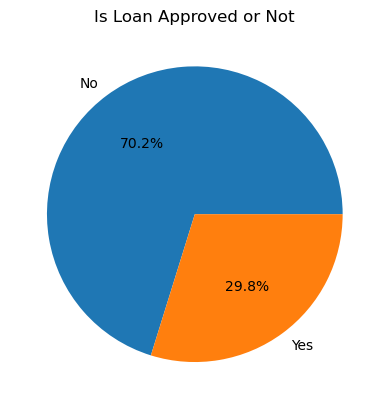

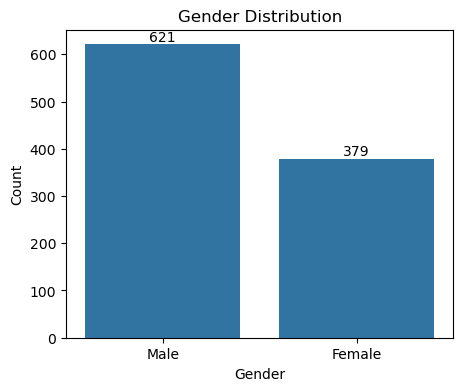

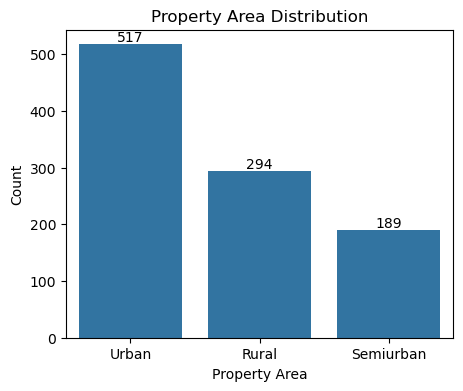

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("loan_approvel_data.csv",sep="\t")

# df.info()

numerical_cols=df.select_dtypes(include=["number"]).columns
numerical_cols

categorical_cols=df.select_dtypes(include=["object"]).columns
categorical_cols

## fill missing values
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy="mean")
df[numerical_cols]=num_imputer.fit_transform(df[numerical_cols])
#df.head()

categorical_imputer= SimpleImputer(strategy="most_frequent")
df[categorical_cols]=categorical_imputer.fit_transform(df[categorical_cols])
df

## EDA
classes_count = df["Loan_Approved"].value_counts()

plt.pie(classes_count,
        labels=["No", "Yes"],
        autopct="%1.1f%%")
plt.title("Is Loan Approved or Not")
plt.show()


gender_cnt = df["Gender"].value_counts()

plt.figure(figsize=(5,4))
plot = sns.barplot(
    x=gender_cnt.index,
    y=gender_cnt.values
)

plot.bar_label(plot.containers[0])
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()


#plot education
area_cnt = df["Property_Area"].value_counts()

plt.figure(figsize=(5,4))
area_plot = sns.barplot(
    x=area_cnt.index,
    y=area_cnt.values
)

area_plot.bar_label(area_plot.containers[0])
plt.title("Property Area Distribution")
plt.xlabel("Property Area")
plt.ylabel("Count")
plt.show()


<Axes: xlabel='Applicant_Income', ylabel='Count'>

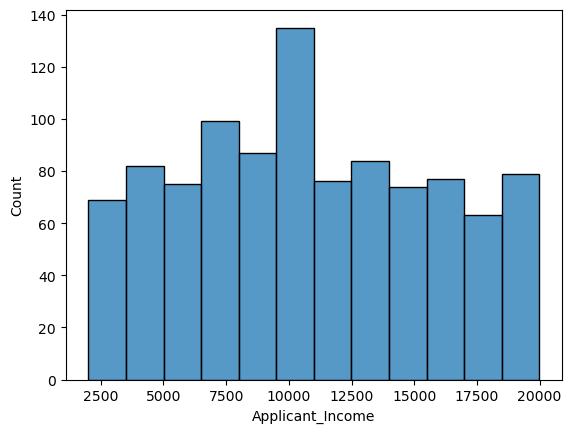

In [40]:
# analyze income 


sns.histplot(
    data=df,
    x="Applicant_in"
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

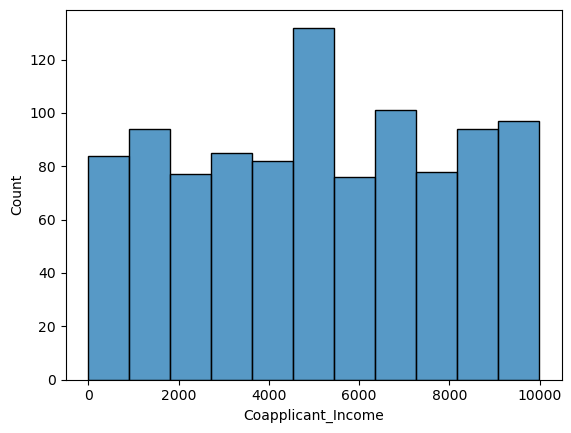

In [41]:
sns.histplot(
    data=df,
    x="Coapplicant_Income"
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

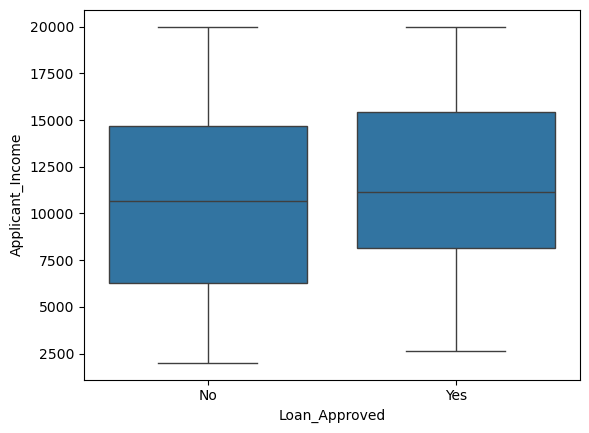

In [43]:
# outliers , boxplot

sns.boxplot(
    data=df,
    x="Loan_Approved",
    y="Applicant_Income"
)

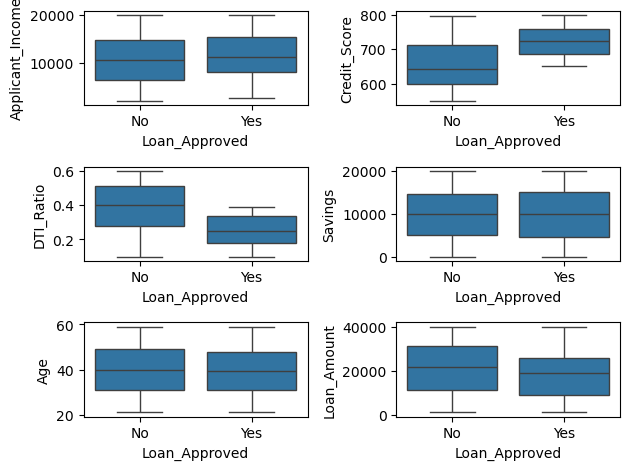

In [49]:
fig,axes=plt.subplots(3,2)

sns.boxplot(ax=axes[0][0],data=df,x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax=axes[0][1],data=df,x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax=axes[1][0],data=df,x="Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax=axes[1][1],data=df,x="Loan_Approved",y="Savings")
sns.boxplot(ax=axes[2][0],data=df,x="Loan_Approved",y="Age")
sns.boxplot(ax=axes[2][1],data=df,x="Loan_Approved",y="Loan_Amount")
plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

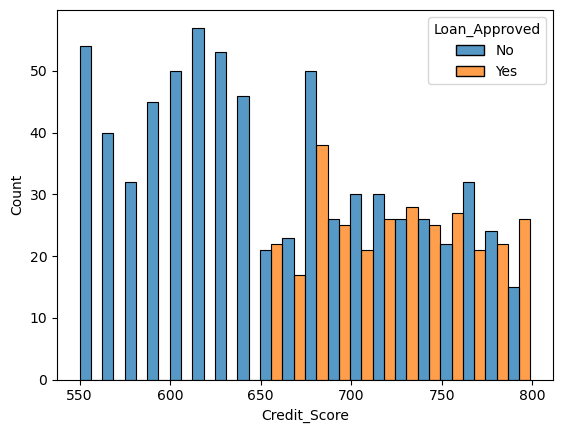

In [51]:
#loan_approved for credit_score

sns.histplot(
    data=df,
    x="Credit_Score",
    bins=20,
    hue="Loan_Approved",
    multiple="dodge"
)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

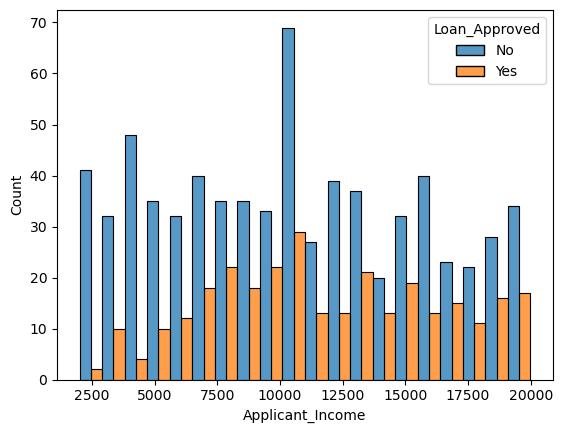

In [52]:

#loan_approved for income
sns.histplot(
    data=df,
    x="Applicant_Income",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

In [53]:
# remove unnasecery feature
df=df.drop("Applicant_ID",axis=1)
df

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.000000,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.000000,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.000000,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.000000,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.000000,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10852.571579,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,72.0,Personal,Urban,Not Graduate,Male,Unemployed,No
996,3279.000000,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,15192.000000,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,9083.000000,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes


<Axes: >

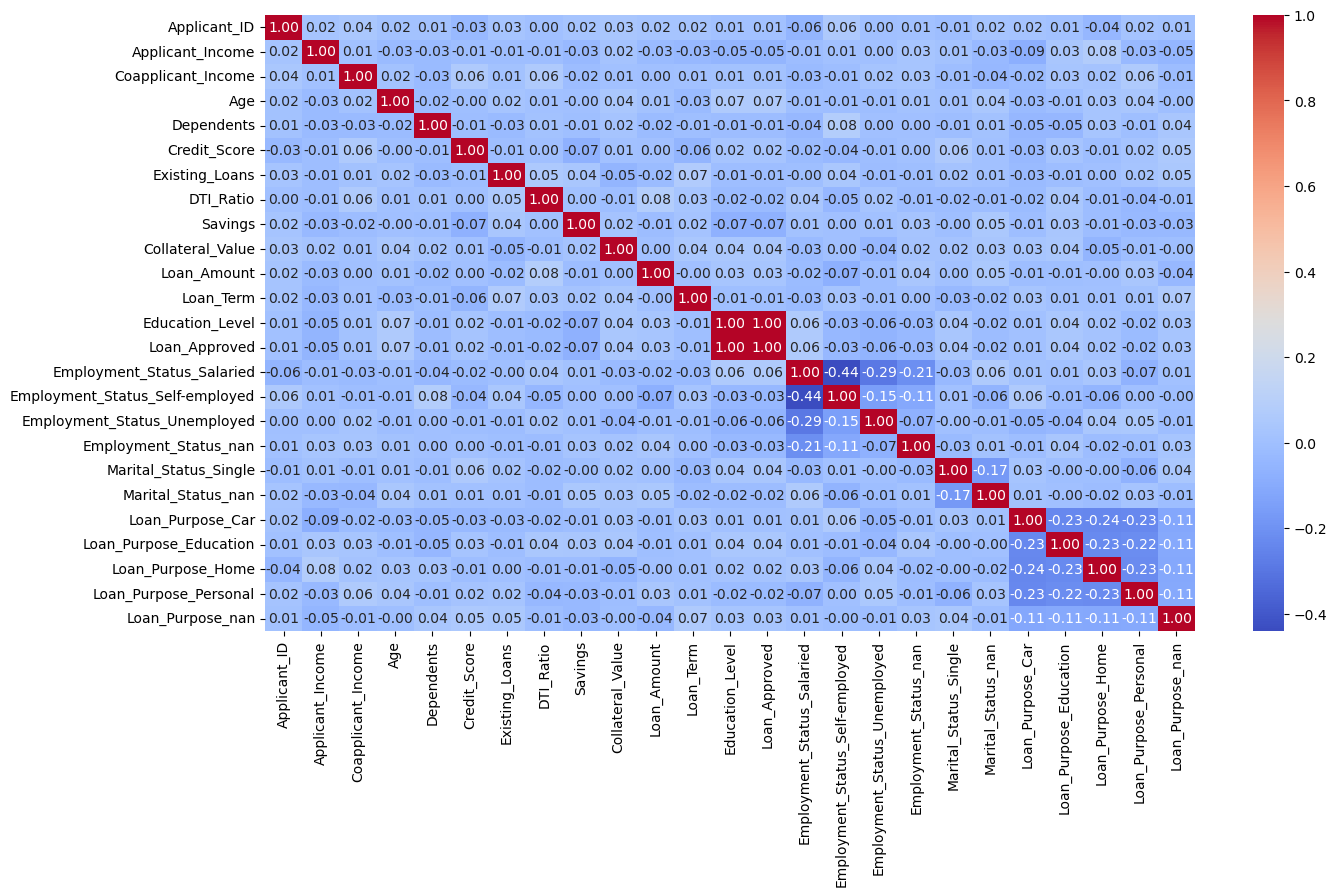

In [3]:
## Encoding variables , means converting into integer
# ways : 1] binary encoding ,2]oneHot encoding , 3]label_incoder ,4]oneHotEncoder

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

le=LabelEncoder()
df=pd.read_csv("loan_approvel_data.csv",sep="\t")
df["Education_Level"]=le.fit_transform(df["Education_Level"])
df["Loan_Approved"] =le.fit_transform(df["Education_Level"])
df.head()

#oneHotEncoding
cols=["Employment_Status","Marital_Status","Loan_Purpose"]#cols for encoding
o_h_e=OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")
encoded=o_h_e.fit_transform(df[cols])#returns dataframe

encoded_df=pd.DataFrame(encoded,columns=o_h_e.get_feature_names_out(cols),index=df.index)
#encoded_df.head()

#append in real data
df=pd.concat([df.drop(columns=cols),encoded_df],axis=1) #drop(columns=cols)>> This removes those columns from the dataframe
#df.head()

num_cols=df.select_dtypes(include="number")
corr_matrix=num_cols.corr()#ACreating the correlation matrix
num_cols.corr()["Loan_Approved"].sort_values(ascending=False)# ["Loan_Approved"] → select only correlations with target e.i. loan_approved
# Helps in feature selection
# Shows which features affect loan approval the most
#Heatmap mean plot these data 

plt.figure(figsize=(15,8)) # increasing size of graph
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
## dark blue shows more negative correlation , and viceversa

In [7]:
# Train ,test ,split + Feature scaling
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

#oneHot encoding
cat_cols = df.select_dtypes(include="object").columns
#cat_cols
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df.head()

X=df.drop("Loan_Approved",axis=1)
y=df["Loan_Approved"]
#X.head()

# Numerical imputation
num_cols = X.select_dtypes(include="number").columns
num_imputer = SimpleImputer(strategy="mean")
X[num_cols] = num_imputer.fit_transform(X[num_cols])

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

#X_train_scaled

#evaluate models
from sklearn.metrics import r2_score , mean_squared_error , mean-absolute_error
print("r2_score:",r2_score(y_test,y_pred))
print("MSE:",mean_squared_error(y_test,y_pred))
print("MAE",mean_absolute_error(y_test,y_pred))


NameError: name 'df' is not defined

In [ ]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score
log_model=LogisticRegression()
log_model.fit(X_train_scaled,y_train)

y_predict=log_model.predict(X_test_scaled)
y_predict

#Evaluation
print("Logistic regression model ")
print("precision:",precision_score(y_test,y_predict,average="weighted")) # consider precision according to problem,nahimilne walo ko bhi loan milra
print("Recall:",recall_score(y_test,y_predict,average="weighted"))
print("f1_score:",f1_score(y_test,y_predict,average="weighted"))
print("Accuracy:",accuracy_score(y_test,y_predict))
print("Cunfusion_matrix:",confusion_matrix(y_test,y_predict))

#KNN model >> not give best becoz large number of inputs
from sklearn.neighbors import KNeighborsClassifier
knn_model=KNeighborsClassifier(n_neighbors=8) # It tells the model to look at the 5 closest data points (neighbors) to make a prediction for a new input.
knn_model.fit(X_train_scaled,y_train)

y_predict=knn_model.predict(X_test_scaled)
#y_predict

#Evaluation
print("\n")
print("KNN model ")
print("precision:",precision_score(y_test,y_predict,average="weighted")) # consider precision according to problem,nahimilne walo ko bhi loan milra
print("Recall:",recall_score(y_test,y_predict,average="weighted"))
print("f1_score:",f1_score(y_test,y_predict,average="weighted"))
print("Accuracy:",accuracy_score(y_test,y_predict))
print("Cunfusion_matrix:",confusion_matrix(y_test,y_predict))



In [ ]:
#Naive Bayes

from sklearn.naive_bayes import GaussianNB
nb_model=GaussianNB()
nb_model.fit(X_train_scaled,y_train)

y_predict=nb_model.predict(X_test_scaled)
#y_predict

#Evaluation
print("\n")
print("Naive bayes model ")
print("precision:",precision_score(y_test,y_predict,average="weighted")) # consider precision according to problem,nahimilne walo ko bhi loan milra
print("Recall:",recall_score(y_test,y_predict,average="weighted"))
print("f1_score:",f1_score(y_test,y_predict,average="weighted"))
print("Accuracy:",accuracy_score(y_test,y_predict))
print("Cunfusion_matrix:",confusion_matrix(y_test,y_predict))